# Seasonal Agriculture Performance Analysis
**VOIS AICTE Data Analyst Internship : Major Project**

**Done By:** ACSAH PAULINE K

---
## 1. Introduction

This project analyzes agricultural performance across three Indian cropping seasons — **Kharif, Rabi, and Zaid** — using a dataset of 4,000 farm-level records spanning 8 states and 8 crops. The goal is not to summarize the dataset in general, but to investigate a focused question: **how and why does agricultural performance actually change from season to season, and what should stakeholders do about it?**


## 2. Problem Statement & Objective

Agricultural outcomes (yield, cost, profit, resource use) are widely believed to shift with the season due to environmental and market conditions. But raw data alone doesn't explain *what* changes, *how much*, or *why*. This notebook investigates seasonal differences in performance to surface patterns that can support evidence-based agricultural planning.

### My Analytical Questions
Rather than answering the brief's question list literally, I narrowed it to four specific, testable questions:

1. **Profitability:** How does profit vary across seasons, and is that variation consistent across all crops — or is it really a *crop* effect hiding behind a *season* label?
2. **Unusual patterns:** Are there crops or regions that defy the overall seasonal trend?
3. **Drivers of yield:** Which factors — environmental (rainfall, temperature, soil) or crop/resource-related — actually correlate with yield across seasons?
4. **Statistical significance:** Are the seasonal differences in yield and profit statistically significant, or could they be noise?


## 3. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 4. Data Understanding

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [4]:
print("Seasons:", df['Season'].unique())
print("States (", df['State'].nunique(), "):", df['State'].unique())
print("Crops (", df['Crop'].nunique(), "):", df['Crop'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())


Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
States ( 8 ): <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Crops ( 8 ): <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:")
print(missing)
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


## 5. Data Cleaning

Three columns have missing values: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` (all under 50 rows, ~1% each). Rather than a blanket fill or dropping rows, I impute using the **median of the same Season + Crop group** — since rainfall and yield are highly crop- and season-specific (e.g. Sugarcane yield is naturally ~20x higher than Pulses), a global median would distort the data.


In [6]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


**Outlier sanity check:** `Yield_Tonnes_Ha` has values ranging from 0.3 to over 100. This looks like an outlier at first glance — but it isn't. Sugarcane is measured in far higher tonnes/hectare than grain crops by nature of the crop, not a data error.


In [7]:
df.groupby('Crop')['Yield_Tonnes_Ha'].describe()[['mean','min','max']].round(2)


,mean,min,max
Crop,,,
Chilli,1.54,0.30,3.90
Cotton,1.23,0.30,2.90
Groundnut,1.32,0.30,3.02
Maize,2.72,0.30,6.08
Pulses,0.92,0.30,2.09
Rice,2.44,0.30,5.70
Sugarcane,46.93,1.39,101.44
Wheat,2.11,0.30,4.56


In [8]:
# Sanity check: does Profit = Revenue - Cost hold?
diff = (df['Revenue_INR'] - df['Total_Cost_INR'] - df['Profit_INR']).abs().max()
print("Max discrepancy in Profit = Revenue - Cost:", diff)

# Derived column used throughout the analysis
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100


Max discrepancy in Profit = Revenue - Cost: 0


## 6. Season Overview

Before diving into the specific questions, a quick look at how records are distributed.


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


/tmp/ipykernel_566/1097709721.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', order=['Kharif','Rabi','Zaid'], palette='Set2')


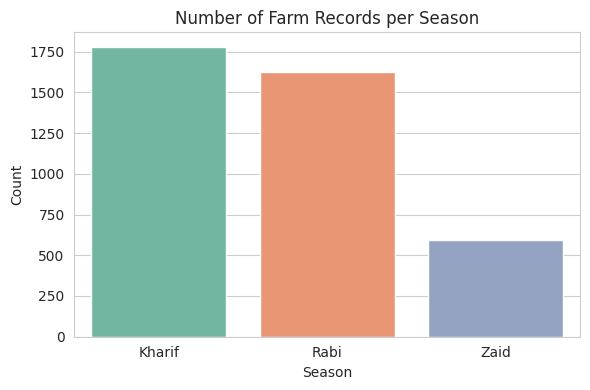

In [9]:
season_counts = df['Season'].value_counts()
print(season_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Season', order=['Kharif','Rabi','Zaid'], palette='Set2')
plt.title('Number of Farm Records per Season')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('01_season_counts.png')
plt.show()


Zaid has notably fewer records than Kharif/Rabi (~594 vs ~1,700+ each) — expected, since Zaid is a short summer season between the two main cropping seasons and fewer crops are grown then.


---
## Question 1: How does profitability vary across seasons, and is it consistent across crops?


In [10]:
season_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Margin_pct=('Profit_Margin_pct', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Records=('Farm_ID', 'count')
).round(2).reindex(['Kharif','Rabi','Zaid'])
season_summary


,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Margin_pct,Avg_Cost_INR,Records
Season,,,,,
Kharif,5.63,178914.65,-38.64,531804.41,1779
Rabi,5.09,87689.47,-44.27,513836.58,1627
Zaid,4.64,-24804.82,-69.35,543976.73,594


/tmp/ipykernel_566/2618821710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', order=['Kharif','Rabi','Zaid'], palette='Set2')


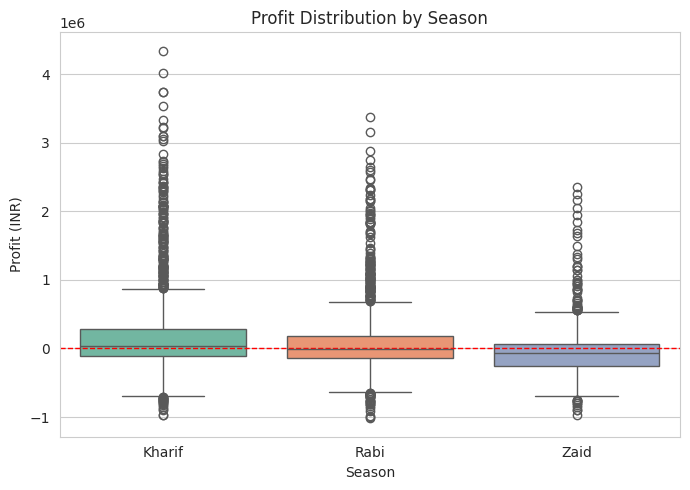

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Profit_INR', order=['Kharif','Rabi','Zaid'], palette='Set2')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit Distribution by Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.savefig('02_profit_by_season.png')
plt.show()


**Finding:** Average profit drops sharply from Kharif (₹1,78,915) to Rabi (₹87,689) to Zaid, which is **negative on average (-₹24,805)**. At first glance this suggests Zaid is simply a bad season to farm in — but that's misleading. Let's break it down by crop.


In [12]:
profit_pivot = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')[['Kharif','Rabi','Zaid']].round(0)
profit_pivot.sort_values('Zaid')


Season,Kharif,Rabi,Zaid
Crop,,,
Rice,-64903.0,-98428.0,-227239.0
Maize,-39333.0,-89133.0,-194049.0
Wheat,-105872.0,-119955.0,-193209.0
Pulses,43339.0,-14309.0,-139228.0
Groundnut,108265.0,10417.0,-68872.0
Cotton,217000.0,107344.0,-53925.0
Chilli,954380.0,638572.0,448659.0
Sugarcane,1000791.0,731613.0,583636.0


<Figure size 1000x600 with 0 Axes>

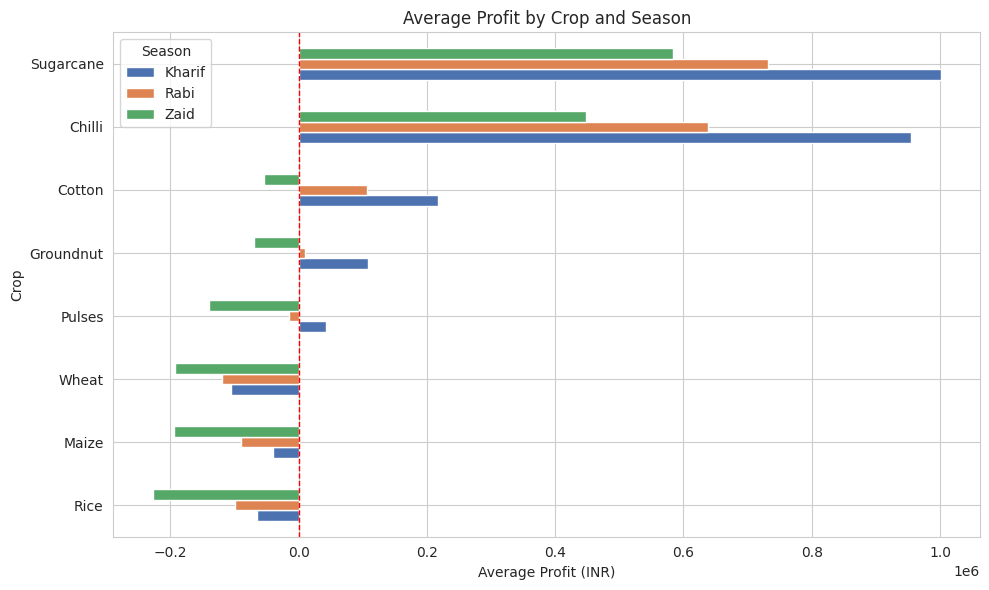

In [13]:
plt.figure(figsize=(10,6))
profit_pivot.sort_values('Zaid').plot(kind='barh', figsize=(10,6), color=['#4C72B0','#DD8452','#55A868'])
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Average Profit by Crop and Season')
plt.xlabel('Average Profit (INR)')
plt.tight_layout()
plt.savefig('03_profit_crop_season.png')
plt.show()


**Real finding:** The Zaid "loss" is not a season-wide effect — it's almost entirely driven by **grain and staple crops** (Rice, Wheat, Maize, Pulses), which post consistent losses in *every* season and simply get worse in Zaid due to added heat/water stress. Meanwhile, **Chilli and Sugarcane stay comfortably profitable in all three seasons**, including Zaid. So the honest conclusion is: *it's not that Zaid is unprofitable — it's that grain crops are structurally unprofitable in this dataset, and Zaid amplifies it.*


---
## Question 2: Are there crops or regions that defy the overall seasonal trend?


In [14]:
zaid = df[df['Season'] == 'Zaid']
zaid_crop_profit = zaid.groupby('Crop')['Profit_INR'].mean().sort_values()
print("Zaid average profit by crop:")
print(zaid_crop_profit.round(0))


Zaid average profit by crop:
Crop
Rice        -227239.0
Maize       -194049.0
Wheat       -193209.0
Pulses      -139228.0
Groundnut    -68872.0
Cotton       -53925.0
Chilli       448659.0
Sugarcane    583636.0
Name: Profit_INR, dtype: float64


Chilli and Sugarcane are clear exceptions — high-value commercial crops that remain profitable even in the toughest season, unlike staple grains. Now check whether the Zaid loss is uniform across states, or concentrated in specific regions.

Zaid average profit by state:
State
Gujarat          -106930.0
Andhra Pradesh    -84085.0
Maharashtra       -40598.0
Telangana         -34621.0
Tamil Nadu        -15175.0
Madhya Pradesh       210.0
Karnataka          23311.0
Punjab             62110.0
Name: Profit_INR, dtype: float64


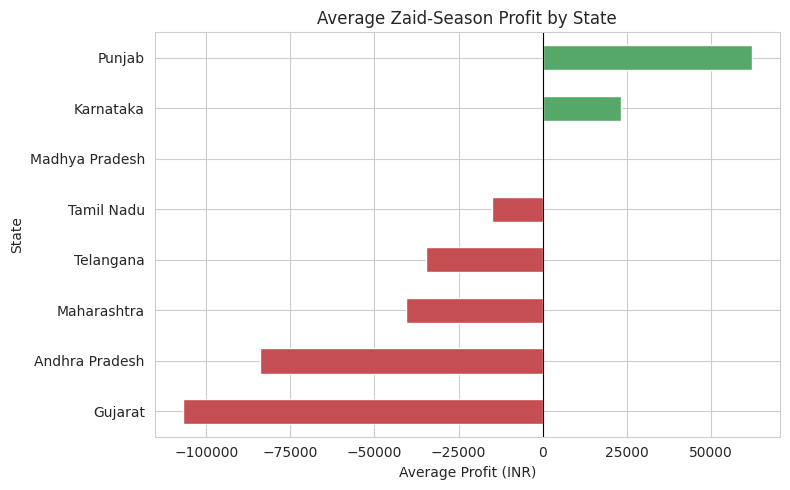

In [15]:
zaid_state_profit = zaid.groupby('State')['Profit_INR'].mean().sort_values()
print("Zaid average profit by state:")
print(zaid_state_profit.round(0))

plt.figure(figsize=(8,5))
zaid_state_profit.plot(kind='barh', color=zaid_state_profit.apply(lambda x: '#C44E52' if x < 0 else '#55A868'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Average Zaid-Season Profit by State')
plt.xlabel('Average Profit (INR)')
plt.tight_layout()
plt.savefig('04_zaid_state_profit.png')
plt.show()


**Finding:** The Zaid loss is *not* uniform across India. Gujarat and Andhra Pradesh post the steepest Zaid losses, while **Punjab and Karnataka stay net-positive even in Zaid**. This points to regional cropping-pattern or resource-management differences rather than a purely climatic explanation — worth flagging for state-level agricultural planning rather than a blanket seasonal policy.


---
## Question 3: Which factors actually drive yield across seasons — environmental or resource-related?


In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
yield_corr = df[numeric_cols].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False)
yield_corr


Water_Efficiency_t_per_1000m3    0.915517
Production_Tonnes                0.885442
Profit_INR                       0.489350
Revenue_INR                      0.433033
Water_Used_m3                    0.387373
Profit_Margin_pct                0.205448
Nitrogen_kg_ha                   0.053633
Phosphorus_kg_ha                 0.046685
Total_Cost_INR                   0.030892
Farm_Area_Hectares               0.030544
Rainfall_mm                      0.026858
Disease_Pest_Risk_pct            0.012464
Humidity_pct                     0.010651
Soil_Moisture_pct                0.010065
Avg_Temperature_C                0.009153
Potassium_kg_ha                  0.005127
Fertilizer_kg_ha                -0.000414
Seed_Quality_Score              -0.007764
Pesticide_Litre_ha              -0.008598
Sunlight_Hours_Day              -0.015462
Soil_pH                         -0.021767
Market_Price_INR_Tonne          -0.384273
Name: Yield_Tonnes_Ha, dtype: float64

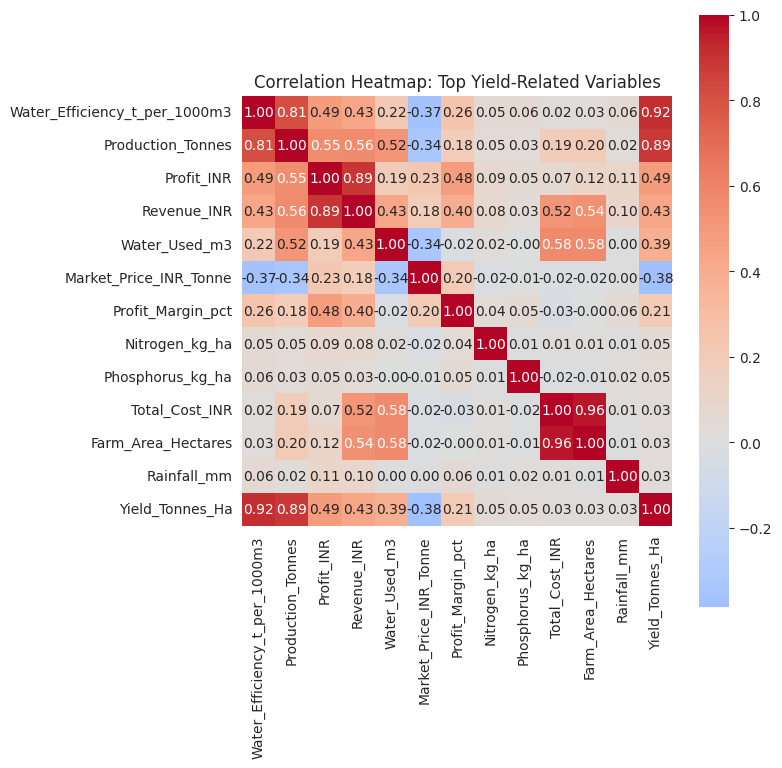

In [17]:
plt.figure(figsize=(8,8))
top_corr_cols = list(yield_corr.abs().sort_values(ascending=False).head(12).index) + ['Yield_Tonnes_Ha']
corr_matrix = df[top_corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap: Top Yield-Related Variables')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png')
plt.show()


**Finding — and it's a counter-intuitive one:** Environmental variables (rainfall, temperature, humidity, soil moisture, soil pH) show **near-zero correlation** with yield (all under 0.03). Even `Disease_Pest_Risk_pct`, which the dataset explicitly tracks, has essentially no linear relationship with yield (r ≈ 0.01). The strongest correlates of yield are actually **Profit, Revenue, and Water Used** — but these are confounded by crop type (e.g. Sugarcane is measured and priced on a completely different scale than Pulses), not causal drivers.

**Practical takeaway:** in this dataset, *which crop is grown* explains far more of the yield variation than *which season or environmental condition* it's grown in. This is useful for planning — it suggests crop selection matters more than fighting seasonal environmental variation for these farms.


Average disease/pest risk by season:
Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


/tmp/ipykernel_566/3941780736.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=['Kharif','Rabi','Zaid'], palette='Set2')


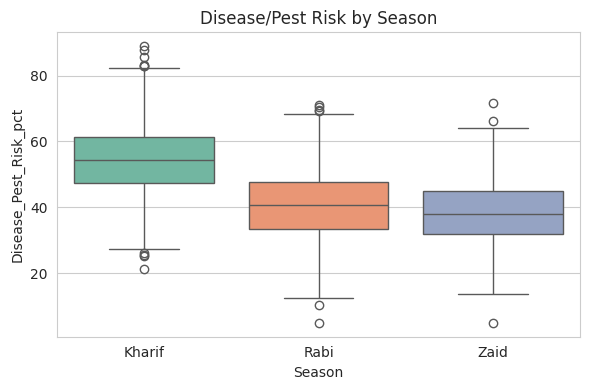

In [18]:
season_disease = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2)
print("Average disease/pest risk by season:")
print(season_disease)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=['Kharif','Rabi','Zaid'], palette='Set2')
plt.title('Disease/Pest Risk by Season')
plt.tight_layout()
plt.savefig('06_disease_risk_season.png')
plt.show()


Kharif does carry the highest disease/pest risk on average (monsoon humidity is the likely driver), but as shown above, this elevated risk doesn't translate into lower yield in the data — Kharif still has the *highest* average yield of the three seasons.

---
## Question 4: Are the seasonal differences statistically significant?

Yield and profit are not normally distributed (heavy right skew from crops like Sugarcane), so I use the **Kruskal-Wallis H-test** — a non-parametric alternative to one-way ANOVA — rather than assuming normality.


In [19]:
yield_groups = [g['Yield_Tonnes_Ha'].values for _, g in df.groupby('Season')]
profit_groups = [g['Profit_INR'].values for _, g in df.groupby('Season')]

h_yield, p_yield = stats.kruskal(*yield_groups)
h_profit, p_profit = stats.kruskal(*profit_groups)

print(f"Yield across seasons  -> H = {h_yield:.2f}, p = {p_yield:.2e}")
print(f"Profit across seasons -> H = {h_profit:.2f}, p = {p_profit:.2e}")


Yield across seasons  -> H = 70.26, p = 5.52e-16
Profit across seasons -> H = 101.93, p = 7.36e-23


**Finding:** Both tests return p-values far below 0.001, so the seasonal differences in yield and profit are **statistically significant** — they are not explained by random noise. Combined with Q1–Q3, though, the *practical* driver of that significance is crop mix and regional factors riding along with season, not season in isolation.


---
## Additional Check: Does irrigation strategy shift across seasons?

One possible explanation for the profit gap: maybe farmers switch irrigation methods to cope with different seasons.


In [20]:
irrigation_mix = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').round(2)
irrigation_mix = irrigation_mix.reindex(['Kharif','Rabi','Zaid'])
irrigation_mix


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,0.23,0.33,0.26,0.18
Rabi,0.23,0.32,0.27,0.18
Zaid,0.24,0.33,0.24,0.20


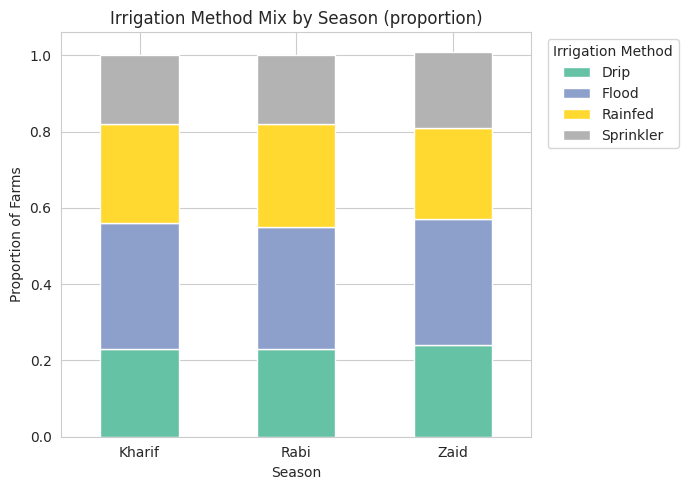

In [21]:
irrigation_mix.plot(kind='bar', stacked=True, figsize=(7,5), colormap='Set2')
plt.title('Irrigation Method Mix by Season (proportion)')
plt.ylabel('Proportion of Farms')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig('07_irrigation_mix.png')
plt.show()


**Finding:** Irrigation method mix is essentially **identical across all three seasons** (Flood ~32-33%, Rainfed ~24-27%, Drip ~23-24%, Sprinkler ~18-20%). Farmers are not adapting irrigation strategy to season in this data — which means the profit gap in Zaid isn't an irrigation story either. It reinforces the Q1/Q3 conclusion: **crop choice**, not resource strategy or environment, is the dominant lever.


---
## 7. Key Insights

1. **The "Zaid is unprofitable" narrative is misleading.** Average Zaid profit is negative, but this is driven almost entirely by staple grain crops (Rice, Wheat, Maize, Pulses) that are already thin-margin or loss-making in every season. High-value crops like Chilli and Sugarcane stay profitable in Zaid too.
2. **Regional inconsistency in Zaid performance.** Punjab and Karnataka remain net-positive in Zaid while Gujarat and Andhra Pradesh post the steepest losses — a state-level, not purely seasonal, pattern.
3. **Environmental conditions barely correlate with yield in this dataset** (rainfall, temperature, soil moisture, disease/pest risk all under |0.05| correlation). Crop type dominates yield outcomes far more than season-linked environmental variation.
4. **Kharif carries the highest disease/pest risk on average, but also the highest yield** — risk score alone is not a reliable yield predictor here.
5. **Irrigation strategy doesn't shift with season**, ruling out resource-strategy adaptation as the explanation for seasonal profit gaps.
6. **Seasonal differences in yield and profit are statistically significant** (Kruskal-Wallis, p < 0.001), but the practical driver is the crop/region mix riding along with season, not season as an isolated factor.


## 8. Recommendations

- **Move planning focus from "season" to "crop-season fit."** Rather than treating Zaid as a universally weak season, planning should flag which *specific crops* are structurally loss-making (Rice, Wheat, Maize, Pulses in this dataset) regardless of season, and support diversification toward higher-margin crops like Chilli/Sugarcane where agronomically feasible.
- **Investigate Gujarat and Andhra Pradesh's Zaid performance specifically** — since Punjab and Karnataka manage to stay profitable in the same season, there may be transferable practices (irrigation timing, crop variety, market access) worth studying.
- **Don't over-index on environmental monitoring as a yield predictor** in this dataset — resources may be better spent on crop-selection and market-price strategy, since these showed stronger ties to profitability than rainfall/temperature/soil metrics.
- **Re-examine disease/pest-risk scoring.** Since it doesn't correlate with actual yield outcomes here, either the risk metric needs refinement or pest/disease management is already effectively neutralizing its impact — worth a targeted follow-up study.


## 9. Conclusion

Seasonal agricultural performance in this dataset is real and statistically significant — but the *season* label is largely a proxy for *which crops get planted* and *where*. Kharif and Rabi outperform Zaid mainly because grain crops dominate all seasons and simply perform worst under Zaid's added heat/water stress, while commercial crops like Chilli and Sugarcane hold their profitability regardless of season. For agricultural planning, the more actionable lever is **crop and regional strategy**, not treating Zaid as an inherently weak season to be avoided.
